# Vectorization — Writing Fast NumPy and Pandas Code

Every dataset in this course is an array: thousands of home prices, tens of thousands of pixels,
millions of tokens. How you write the arithmetic over those arrays decides whether a cell returns
instantly or does not finish at all. Python's own `for` loop is the slow way, and it is slow by a
factor of hundreds — not percent. This notebook writes the same calculation three ways, times
each one, and explains where the difference comes from.

## Learning objectives

- Explain why a Python-level loop is far slower than the equivalent NumPy/pandas operation
- Apply a vectorized arithmetic operation to an entire `Series` at once
- Distinguish true vectorization from `.apply()`, which still runs a Python loop underneath
- Time a cell with the `%%time` magic and compare the three approaches on the same data

## Background

This notebook assumes ordinary Python — variables, `for` loops, and `lambda` — and nothing more.
A `pandas.Series` is a one-dimensional column of values with an index, and a `numpy.ndarray` is
the raw typed buffer underneath it; both are introduced here as they are used.

**Prerequisites:** none — this is the first notebook of the course.

**Dataset:** none — a synthetic array of random values generated in the notebook.

**References:** https://numpy.org/doc/stable/user/basics.broadcasting.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Create a Series

One million random values between 0 and 1. A million is small by the standards of real data, but
it is more than enough to make the three approaches below separate by orders of magnitude.

The values live in a contiguous block of memory as 64-bit floats — that layout is the whole
reason the fast version is fast, because compiled code can walk the block without ever asking the
Python interpreter what any individual element is.

In [2]:
N = int(1e6)

x = pd.Series(np.random.rand(N))
x

0         0.204063
1         0.363361
2         0.883706
3         0.597743
4         0.432348
            ...   
999995    0.987955
999996    0.480088
999997    0.326544
999998    0.366661
999999    0.498146
Length: 1000000, dtype: float64

## 2. Vectorized arithmetic (the magic method)

The task is to square every element:

$$z_i = x_i^2, \qquad i = 1, 2, \ldots, N$$

Writing `x**2` does *not* mean "loop over `x`." Python sees the `**` operator and calls the
Series' `__pow__` magic method, which hands the entire underlying buffer to compiled C code. One
Python-level call happens; the million multiplications happen underneath it, in a language with
no interpreter overhead.

That difference has a simple cost model. Let $t_{\text{op}}$ be the cost of one multiplication in
compiled code and $t_{\text{interp}}$ be the cost of one trip through the Python interpreter —
bytecode dispatch, type checks, allocating a boxed float object for the result. Then

$$T_{\text{vec}} \approx t_{\text{call}} + N\,t_{\text{op}}
\qquad\text{versus}\qquad
T_{\text{loop}} \approx N\,\left(t_{\text{interp}} + t_{\text{op}}\right)$$

For arithmetic this simple, $t_{\text{interp}} \gg t_{\text{op}}$ — the bookkeeping around the
multiplication costs far more than the multiplication. The vectorized form pays that overhead
**once**; the loop pays it $N$ times. That ratio is what the timings below measure.

The `%%time` magic at the top of a cell reports how long the whole cell took.

In [3]:
%%time

z = x**2

CPU times: total: 0 ns
Wall time: 2 ms


## 3. `.apply()` — a loop in disguise

`.apply()` *looks* like the vectorized version: one method call on the whole Series, no visible
loop. But look at what it is given — a Python `lambda`. A Python function can only be called by
the Python interpreter, so `.apply()` must walk the Series and invoke that function once per
element, boxing each value on the way in and the result on the way out.

In the cost model above, `.apply()` sits on the $T_{\text{loop}}$ side: it pays
$t_{\text{interp}}$ $N$ times. It is more convenient than writing the loop yourself and it reads
better, but it buys **no** speed from vectorization. Reach for it when the operation genuinely
cannot be expressed in array arithmetic — not as a faster alternative to a loop.

In [4]:
%%time

z = x.apply( lambda x: x**2 );

CPU times: total: 266 ms
Wall time: 263 ms


## 4. The explicit Python loop

The version a student writes before learning any of the above. It pays the interpreter overhead
$N$ times like `.apply()` does, and then adds more on top: each iteration performs **two** `.iloc`
lookups — one to read `x`, one to write `z` — and `.iloc` is itself a Python-level indexing
machine that has to resolve a position into the Series' index before touching memory.

This cell is deliberately the slow one. Let it run; the wait is the lesson.

In [5]:
%%time

for i in range(N):
    z.iloc[i] = x.iloc[i]**2

CPU times: total: 29.3 s
Wall time: 29.3 s


## 5. The three side by side

`%%time` prints a result but does not hand us a number we can plot, so here we time all three
again with `time.perf_counter()` and chart them together.

Note the smaller `N` — one tenth of the array above. Benchmarking the slow approach at full size
costs more than the demonstration is worth, which is itself the practical point: once code is
slow enough, you cannot even afford to measure it comfortably.

N = 100,000
  vectorized     0.0003 s   (      1x the vectorized time)
  .apply()       0.0265 s   (     83x the vectorized time)
  for loop       3.0084 s   (  9,404x the vectorized time)


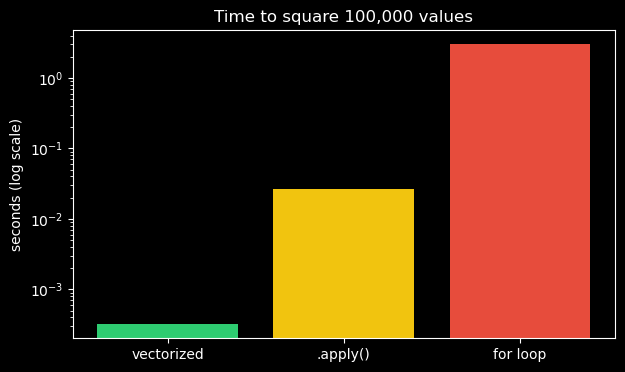

In [6]:
import time

N_bench = int(1e5)
x_bench = pd.Series(np.random.rand(N_bench))

# 1. Vectorized: one call into compiled code.
t0 = time.perf_counter()
z1 = x_bench**2
t_vec = time.perf_counter() - t0

# 2. .apply(): one Python function call per element.
t0 = time.perf_counter()
z2 = x_bench.apply(lambda v: v**2)
t_apply = time.perf_counter() - t0

# 3. Explicit loop: one Python iteration plus two .iloc lookups per element.
z3 = x_bench.copy()
t0 = time.perf_counter()
for i in range(N_bench):
    z3.iloc[i] = x_bench.iloc[i]**2
# end
t_loop = time.perf_counter() - t0

times = pd.Series({'vectorized': t_vec, '.apply()': t_apply, 'for loop': t_loop})

print(f'N = {N_bench:,}')
for name, t in times.items():
    print(f'  {name:12s} {t:8.4f} s   ({t/t_vec:>7,.0f}x the vectorized time)')
# end

plt.figure(figsize=(7,4))
plt.bar(times.index, times.values, color=['#2ecc71', '#f1c40f', '#e74c3c'])
plt.yscale('log')
plt.ylabel('seconds (log scale)')
plt.title(f'Time to square {N_bench:,} values')
plt.show()

The y-axis is logarithmic — on a linear axis the vectorized bar would be invisible. All three
produce identical numbers; only the time differs.

A useful sanity check is that all three really do agree, since a "fast" answer that is also wrong
would not be worth much.

In [7]:
# All three approaches must produce the same values.
print('vectorized == .apply() :', np.allclose(z1, z2))
print('vectorized == for loop :', np.allclose(z1, z3))

vectorized == .apply() : True
vectorized == for loop : True


## 6. Review

- **Vectorized arithmetic pays the interpreter's overhead once; a loop pays it $N$ times.** With
  $T_{\text{vec}} \approx t_{\text{call}} + N\,t_{\text{op}}$ against
  $T_{\text{loop}} \approx N\,(t_{\text{interp}} + t_{\text{op}})$ and
  $t_{\text{interp}} \gg t_{\text{op}}$, the gap grows linearly with the size of the data.
- **Squaring a Series is not shorthand for a loop.** Writing `x**2` dispatches to the Series'
  `__pow__` magic method, which passes the whole memory buffer to compiled code.
- **`.apply()` is not vectorization.** It takes a Python function, so it must call back into the
  interpreter once per element. Use it for logic that array arithmetic cannot express, not as a
  speed-up.
- **`.iloc` in a loop is the worst case**, adding a Python-level index lookup on every read and
  every write on top of the loop overhead already being paid.
- The three approaches return identical values. The only thing that changes is how long you wait —
  which, at the sizes used later in this course, is the difference between a demo that runs and
  one that does not.